In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('olist_cleaned.csv')

In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,TotalPrice
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,19.90


In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [5]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [6]:
snapshot_date

Timestamp('2018-08-30 15:00:37')

In [7]:
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'TotalPrice': 'sum'
})

In [8]:
rfm.columns = ['Recency', 'Frequency', 'Monetry']

In [9]:
rfm.head()

,Recency,Frequency,Monetry
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
0000f46a3911fa3c0805444483337064,537,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
0004aac84e0df4da2b147fca70cf8255,288,1,180.00


In [10]:
rfm.sort_values('Monetry', ascending=True)

,Recency,Frequency,Monetry
customer_unique_id,,,
d80730c15c647bc8f2ad77c908ba5ca9,128,1,0.85
b38211bd797f4fdd81a98b9d1754b606,127,1,0.85
317cfc692e3f86c45c95697c61c853a6,4,1,2.20
bd06ce0e06ad77a7f681f1a4960a3cc6,350,1,2.29
cf3839da0d9492ad151690b65f45d800,209,1,2.99
...,...,...,...
459bef486812aa25204be022145caa62,35,1,6729.00
dc4802a71eae9be1dd28f5d788ceb526,563,1,6735.00
763c8b1c9c68a0229c42c9fc6f662b93,46,1,7160.00


In [11]:
rfm['Monetry'].min()

0.85

In [12]:
rfm['Monetry'].max()

13440.0

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
rfm_scaled = scaler.fit_transform(rfm)

In [18]:
rfm_scaled[:5]

array([[-0.82535715, -0.1598294 , -0.05434338],
       [-0.80569671, -0.1598294 , -0.56896404],
       [ 1.95987274, -0.1598294 , -0.33668931],
       [ 0.54432061, -0.1598294 , -0.53609322],
       [ 0.3280557 , -0.1598294 ,  0.17793134]])

In [19]:
from sklearn.cluster import KMeans

In [20]:
inertia = []

In [21]:
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

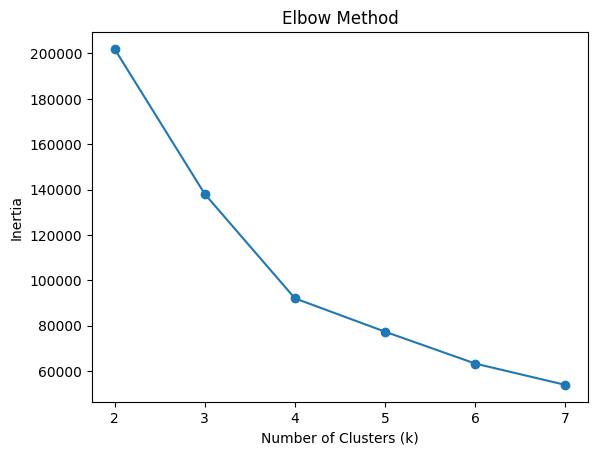

In [22]:
plt.plot(range(2, 8), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [25]:
rfm.head()

,Recency,Frequency,Monetry,Cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0
0000f46a3911fa3c0805444483337064,537,1,69.00,1
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1


In [26]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetry']].mean()

,Recency,Frequency,Monetry
Cluster,,,
0,128.071927,1.000000,113.373904
1,387.338229,1.000000,114.049708
2,237.681133,1.013248,1142.000566
3,220.421413,2.114275,243.161244


In [27]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,50746
1,37649
2,2189
3,2774


In [28]:
cluster_labels = {
    0: 'Recent One-Time Buyers',
    1: 'Lapsed / At Risk',
    2: 'High-Value One-Timers',
    3: 'Repeat Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetry,Cluster,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0,Recent One-Time Buyers
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0,Recent One-Time Buyers
0000f46a3911fa3c0805444483337064,537,1,69.00,1,Lapsed / At Risk
0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1,Lapsed / At Risk
0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1,Lapsed / At Risk


In [29]:
segment_distribution = rfm['Segment'].value_counts(normalize=True) * 100
print(segment_distribution.round(2))

Segment
Recent One-Time Buyers    54.36
Lapsed / At Risk          40.33
Repeat Customers           2.97
High-Value One-Timers      2.34
Name: proportion, dtype: float64


In [30]:
rfm.to_csv('olist_rfm_segments.csv')